In [6]:
# ============================================================
# SECTION 0 — VERIFY DATASET
# 数据已通过 Kaggle 下载完成，仅验证文件路径
# ============================================================

import os
import glob

# 定义数据集路径（和你之前的路径保持一致）
data_path = "/home/wwww/zhj/GAN/data/images"

# 检查数据集文件夹是否存在
if not os.path.exists(data_path):
    raise FileNotFoundError(f"数据集路径不存在：{data_path}，请确认文件位置！")

# 统计所有图片数量
image_files = glob.glob(os.path.join(data_path, "*.jpg"))

# 校验图片是否存在
if len(image_files) == 0:
    raise FileNotFoundError(f"路径 {data_path} 中未找到任何 .jpg 图片！")

# 打印结果
print(f"Total images found: {len(image_files)}")
print("Dataset ready! 可以开始训练啦~")

Total images found: 63565
Dataset ready! 可以开始训练啦~


In [7]:
# ============================================================
# SECTION 1 — IMPORTS
# ============================================================

import os
import glob
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.utils as vutils

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

In [8]:
# ============================================================
# SECTION 2 — CONFIG
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.benchmark = True

DATA_DIR = "/home/wwww/zhj/GAN/data/images"

BATCH_SIZE = 256
IMAGE_SIZE = 64
CHANNELS_IMG = 3

Z_DIM = 128

NUM_EPOCHS = 100

FEATURES_GEN = 64
FEATURES_CRITIC = 64

LR = 1e-4

CRITIC_ITERATIONS = 5
LAMBDA_GP = 10

SAVE_DIR = "outputs_medium"

os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Using device: {DEVICE}")

Using device: cuda


In [9]:
# ============================================================
# SECTION 3 — DATASET
# ============================================================

class AnimeDataset(Dataset):
    def __init__(self, root):
        self.files = glob.glob(os.path.join(root, "*.jpg"))

        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        return self.transform(img)


dataset = AnimeDataset(DATA_DIR)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

In [10]:
# ============================================================
# SECTION 4 — WEIGHT INIT
# ============================================================


def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)

In [11]:
# ============================================================
# SECTION 5 — GENERATOR
# ============================================================

class Generator(nn.Module):
    def __init__(self, z_dim, channels_img, features_g):
        super().__init__()

        self.net = nn.Sequential(
            self._block(z_dim, features_g * 8, 4, 1, 0),
            self._block(features_g * 8, features_g * 4, 4, 2, 1),
            self._block(features_g * 4, features_g * 2, 4, 2, 1),
            self._block(features_g * 2, features_g, 4, 2, 1),
            nn.ConvTranspose2d(features_g, channels_img, 4, 2, 1),
            nn.Tanh()
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

In [12]:
# ============================================================
# SECTION 6 — CRITIC
# ============================================================

class Critic(nn.Module):
    def __init__(self, channels_img, features_d):
        super().__init__()

        self.disc = nn.Sequential(
            nn.Conv2d(channels_img, features_d, 4, 2, 1),
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 4, 2, 1),
            self._block(features_d * 2, features_d * 4, 4, 2, 1),
            self._block(features_d * 4, features_d * 8, 4, 2, 1),
            nn.Conv2d(features_d * 8, 1, 4, 2, 0),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x):
        return self.disc(x)

In [13]:
# ============================================================
# SECTION 7 — GRADIENT PENALTY
# ============================================================


def gradient_penalty(critic, real, fake, device="cpu"):
    BATCH_SIZE, C, H, W = real.shape
    epsilon = torch.rand((BATCH_SIZE, 1, 1, 1)).repeat(1, C, H, W).to(device)

    interpolated_images = real * epsilon + fake * (1 - epsilon)

    mixed_scores = critic(interpolated_images)

    gradient = torch.autograd.grad(
        inputs=interpolated_images,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
    )[0]

    gradient = gradient.view(gradient.shape[0], -1)
    gradient_norm = gradient.norm(2, dim=1)
    gradient_penalty = torch.mean((gradient_norm - 1) ** 2)

    return gradient_penalty

In [14]:
# ============================================================
# SECTION 8 — MODEL INIT
# ============================================================

gen = Generator(Z_DIM, CHANNELS_IMG, FEATURES_GEN).to(DEVICE)
critic = Critic(CHANNELS_IMG, FEATURES_CRITIC).to(DEVICE)

initialize_weights(gen)
initialize_weights(critic)

opt_gen = optim.Adam(gen.parameters(), lr=LR, betas=(0.0, 0.9))
opt_critic = optim.Adam(critic.parameters(), lr=LR, betas=(0.0, 0.9))

fixed_noise = torch.randn(64, Z_DIM, 1, 1).to(DEVICE)

In [15]:
# ============================================================
# SECTION 9 — TRAINING
# ============================================================

print("Starting Training WGAN-GP...")

for epoch in range(NUM_EPOCHS):

    loop = tqdm(loader, leave=True)

    for batch_idx, real in enumerate(loop):
        real = real.to(DEVICE)
        cur_batch_size = real.shape[0]

        for _ in range(CRITIC_ITERATIONS):
            noise = torch.randn(cur_batch_size, Z_DIM, 1, 1).to(DEVICE)
            fake = gen(noise)

            critic_real = critic(real).reshape(-1)
            critic_fake = critic(fake).reshape(-1)

            gp = gradient_penalty(critic, real, fake, device=DEVICE)

            loss_critic = (
                -(torch.mean(critic_real) - torch.mean(critic_fake))
                + LAMBDA_GP * gp
            )

            critic.zero_grad()
            loss_critic.backward(retain_graph=True)
            opt_critic.step()

        output = critic(fake).reshape(-1)
        loss_gen = -torch.mean(output)

        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        loop.set_description(f"Epoch [{epoch}/{NUM_EPOCHS}]")
        loop.set_postfix(
            loss_critic=loss_critic.item(),
            loss_gen=loss_gen.item()
        )

    with torch.no_grad():
        fake = gen(fixed_noise).detach().cpu()

    grid = vutils.make_grid(fake[:64], normalize=True)

    torchvision.utils.save_image(
        grid,
        os.path.join(SAVE_DIR, f"epoch_{epoch}.png")
    )

Starting Training WGAN-GP...


Epoch [99/100]: 100%|██████████| 249/249 [00:32<00:00,  7.72it/s, loss_critic=-6.79e+5, loss_gen=3.05e+5] 


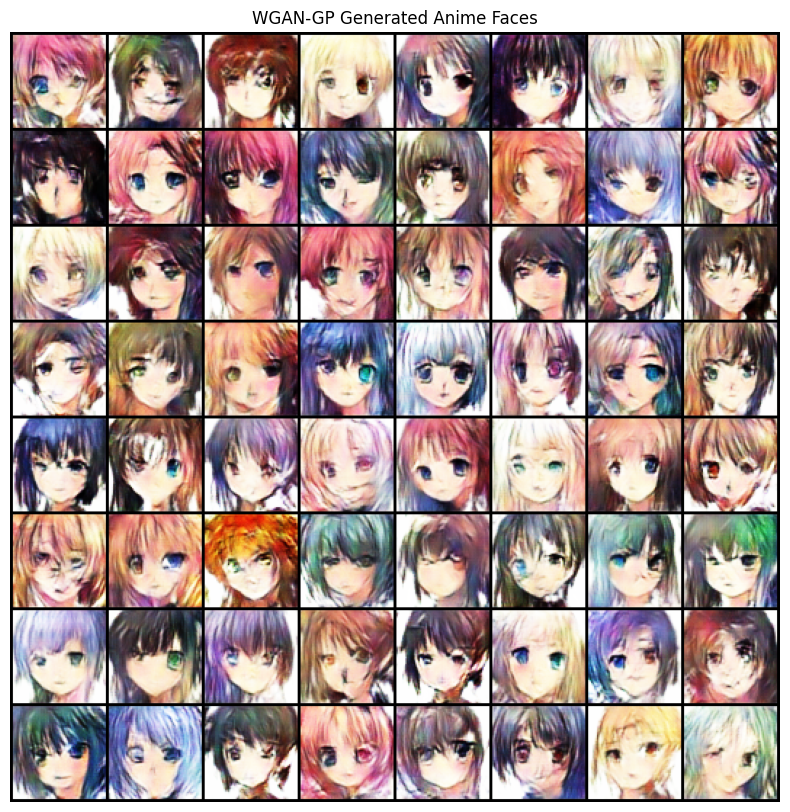

In [17]:
# ============================================================
# SECTION 10 — FINAL IMAGE MATRIX
# ============================================================

plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("WGAN-GP Generated Anime Faces")
plt.imshow(grid.permute(1, 2, 0))
plt.show()